see how well a linear regression model and an MLP can learn the mapping f(embedding) = precipitation for a region and how much better it is over baseline interpolation

In [1]:
import xarray as xr

area_path = "data/northamerica-west-mini/"
# area_path = "data/rainshift_dataset/northamerica-west/"
data_in_area = xr.open_zarr(area_path + "train_data_in.zarr")
data_out_area = xr.open_zarr(area_path + "train_data_out.zarr")
# data_out_area = xr.open_zarr(area_path + "test_data_out.zarr")
# static_variables = xr.open_dataset(area_path + "static_variables.nc")

In [2]:
data_in_area


<xarray.Dataset> Size: 46MB
Dimensions:    (time: 100, latitude: 80, longitude: 80)
Coordinates:
  * time       (time) datetime64[ns] 800B 2001-01-01 ... 2001-01-05T03:00:00
  * latitude   (latitude) float32 320B 60.0 59.75 59.5 ... 40.75 40.5 40.25
  * longitude  (longitude) float32 320B 230.0 230.2 230.5 ... 249.2 249.5 249.8
Data variables:
    cape       (time, latitude, longitude) float64 5MB ...
    cp         (time, latitude, longitude) float64 5MB ...
    sp         (time, latitude, longitude) float64 5MB ...
    tclw       (time, latitude, longitude) float64 5MB ...
    tcw        (time, latitude, longitude) float64 5MB ...
    tisr       (time, latitude, longitude) float64 5MB ...
    tp         (time, latitude, longitude) float64 5MB ...
    u          (time, latitude, longitude) float64 5MB ...
    v          (time, latitude, longitude) float64 5MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-06-05 08:11:26 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

In [3]:
data_out_area

<xarray.Dataset> Size: 16MB
Dimensions:        (time: 100, latitude: 200, longitude: 200)
Coordinates:
  * latitude       (latitude) float32 800B 59.95 59.85 59.75 ... 40.15 40.05
  * longitude      (longitude) float32 800B 230.1 230.2 230.2 ... 249.9 250.0
Dimensions without coordinates: time
Data variables:
    precipitation  (time, latitude, longitude) float32 16MB ...

In [4]:
print(list(data_in_area.data_vars.keys()))

['cape', 'cp', 'sp', 'tclw', 'tcw', 'tisr', 'tp', 'u', 'v']


In [ ]:
static_variables

NameError: name 'static_variables' is not defined

In [6]:
# load satclip model

# Ensure Hugging Face and Torch caches are set before imports
import os
import sys
import pyproj
from huggingface_hub import hf_hub_download
import torch

cwd = os.getcwd()

cache_dir = "/home/sazhang/.cache"
hf_cache = f"{cache_dir}/huggingface"
torch_cache = f"{cache_dir}/torch"

os.environ["HF_HOME"] = hf_cache
os.environ["HF_HUB_CACHE"] = f"{hf_cache}/hub"
os.environ["TRANSFORMERS_CACHE"] = f"{hf_cache}/transformers"
os.environ["TORCH_HOME"] = torch_cache

import importlib
import huggingface_hub.constants as hf_const
importlib.reload(hf_const)
print("HF_HOME:", hf_const.HF_HOME)
print("HF_HUB_CACHE:", hf_const.HF_HUB_CACHE)
print("TORCH_HOME:", os.environ["TORCH_HOME"])


sys.path.append(f'{cwd}/satclip/satclip') # add satclip module from satclip repo to path

# Explicitly set via pyproj API
conda_env_path = "/home/sazhang/miniconda3/envs/downscaling"
proj_path = f"{conda_env_path}/share/proj"

os.environ["PROJ_LIB"] = proj_path
os.environ["PROJ_DATA"] = proj_path

pyproj.datadir.set_data_dir(proj_path)


device = "cuda" if torch.cuda.is_available() else "cpu"

from load import get_satclip
model = get_satclip(
    hf_hub_download("microsoft/SatCLIP-ResNet18-L40", "satclip-resnet18-l40.ckpt", cache_dir=cache_dir),
    device=device,
)  # Only loads location encoder by default


/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HF_HOME: /home/sazhang/.cache/huggingface
HF_HUB_CACHE: /home/sazhang/.cache/huggingface/hub
TORCH_HOME: /home/sazhang/.cache/torch


mkdir -p failed for path /afs/csail.mit.edu/u/s/sazhang/.config/matplotlib: [Errno 13] Permission denied: '/afs/csail.mit.edu/u/s/sazhang/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-tieyje8l because there was an issue with the default path (/afs/csail.mit.edu/u/s/sazhang/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


using pretrained moco resnet18


In [7]:
import numpy as np

# Coordinates
lat = data_out_area['latitude'].values
lon = data_out_area['longitude'].values

# Create a meshgrid
lon_grid, lat_grid = np.meshgrid(lon, lat)

# Flatten
lon_flat = lon_grid.flatten()
lat_flat = lat_grid.flatten()

# SatCLIP takes coordinates as (lon, lat)
coords = np.stack([lon_flat, lat_flat], axis=1)

# Check model dtype
model_dtype = next(model.parameters()).dtype
print(model_dtype)

coords_tensor = torch.tensor(coords, dtype=model_dtype).to(device)
print(coords_tensor.shape)


torch.float64
torch.Size([40000, 2])


In [8]:
# satclip embeddings xarray
# Get embeddings in batches to prevent OOM
batch_size = 4096
embeddings = []
model.eval()

with torch.no_grad():
    for i in range(0, coords_tensor.shape[0], batch_size):
        batch = coords_tensor[i:i+batch_size]
        emb = model(batch)
        embeddings.append(emb.cpu().numpy())

embeddings = np.concatenate(embeddings, axis=0)

# Reshape back to (latitude, longitude, embedding_dim)
emb_dim = embeddings.shape[1]
embeddings_grid = embeddings.reshape((len(lat), len(lon), emb_dim))

print("Embeddings shape:", embeddings_grid.shape)

# Create an xarray DataArray for embeddings
data_out_area['sat_embeddings'] = (('latitude', 'longitude', 'embedding_dim'), embeddings_grid)
print(data_out_area)


Embeddings shape: (200, 200, 256)
<xarray.Dataset> Size: 98MB
Dimensions:         (time: 100, latitude: 200, longitude: 200,
                     embedding_dim: 256)
Coordinates:
  * latitude        (latitude) float32 800B 59.95 59.85 59.75 ... 40.15 40.05
  * longitude       (longitude) float32 800B 230.1 230.2 230.2 ... 249.9 250.0
Dimensions without coordinates: time, embedding_dim
Data variables:
    precipitation   (time, latitude, longitude) float32 16MB ...
    sat_embeddings  (latitude, longitude, embedding_dim) float64 82MB -2.301 ...


Train shapes: X=(36000, 256), y=(36000,)
Test shapes: X=(4000, 256), y=(4000,)


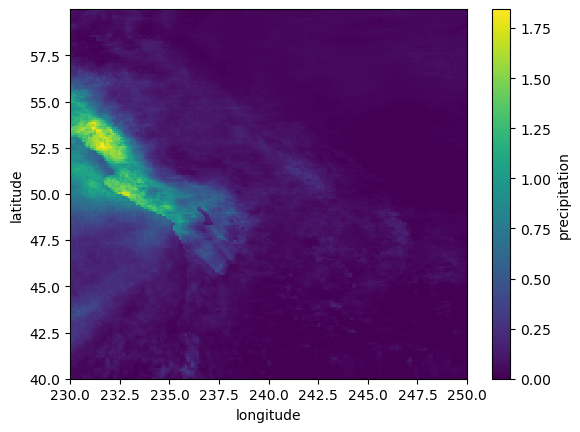

In [9]:
# Prepare data for regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Compute mean precipitation for each location to serve as the target
# Over time
data_out_area["precipitation"].mean(dim="time").plot()

mean_precip = data_out_area['precipitation'].mean(dim='time').values
mean_precip_flat = mean_precip.flatten()

# X is the embeddings
X = embeddings_grid.reshape(-1, emb_dim)
y = mean_precip_flat

# Filter out NaNs if any
mask = ~np.isnan(y) & ~np.isnan(X).any(axis=1)
X = X[mask]
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")


In [13]:
# 1. Regression model
# Using Ridge regression as a robust linear regression model (could also just be LinearRegression)
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))


Linear Regression MSE: 0.002486418270281419
Linear Regression R2: 0.9634680415836219


In [14]:
# 2. Simple MLP
mlp = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=200, random_state=42)
mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)
print("MLP MSE:", mean_squared_error(y_test, y_pred_mlp))
print("MLP R2:", r2_score(y_test, y_pred_mlp))


MLP MSE: 0.0018281215632457322
MLP R2: 0.9731401342538324


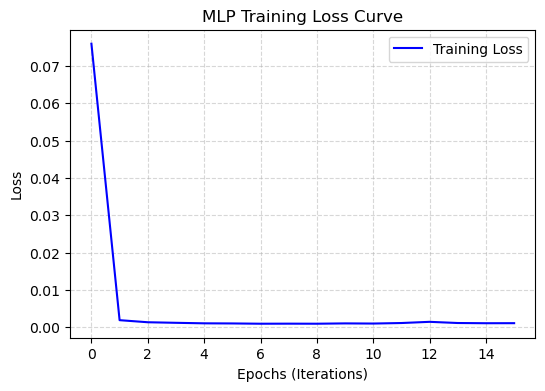

In [15]:
import matplotlib.pyplot as plt

# Plot MLP Training Loss Curve
plt.figure(figsize=(6, 4))
plt.plot(mlp.loss_curve_, label='Training Loss', color='blue')
plt.title('MLP Training Loss Curve')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

--- Linear Regression ---
Deterministic CRPS (MAE): 0.0293
95th Percentile MAE: 0.0927
99th Percentile MAE: 0.2237



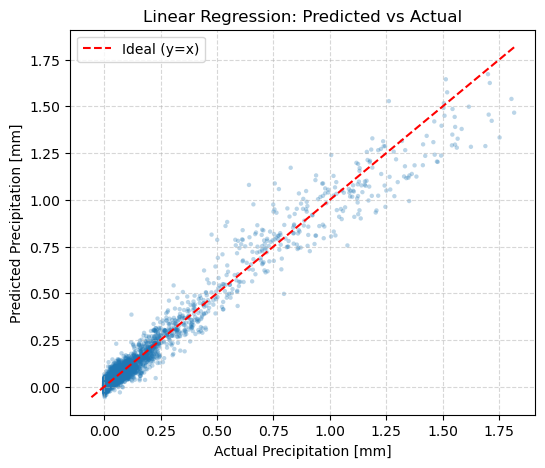

--- Simple MLP ---
Deterministic CRPS (MAE): 0.0281
95th Percentile MAE: 0.0828
99th Percentile MAE: 0.1496



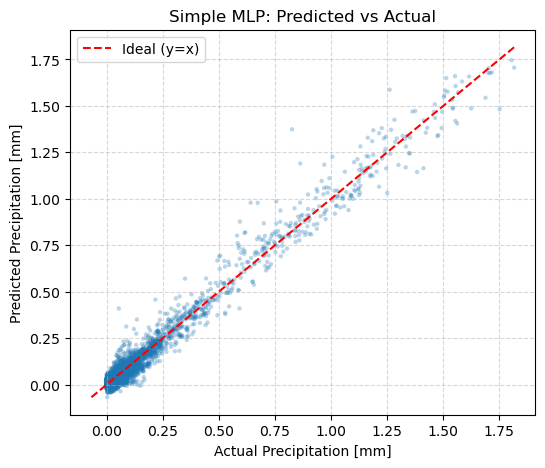

In [16]:
from sklearn.metrics import mean_absolute_error

metrics = {}

def evaluate_and_plot(y_test, y_pred, model_name):
    # Absolute Errors
    abs_errors = np.abs(y_test - y_pred)
    
    # Deterministic CRPS is exactly equivalent to MAE
    mae_crps = mean_absolute_error(y_test, y_pred)
    
    # Percentiles
    mae_95 = np.percentile(abs_errors, 95)
    mae_99 = np.percentile(abs_errors, 99)
    
    print(f"--- {model_name} ---")
    print(f"Deterministic CRPS (MAE): {mae_crps:.4f}")
    print(f"95th Percentile MAE: {mae_95:.4f}")
    print(f"99th Percentile MAE: {mae_99:.4f}")
    print()
    
    # Scatter plot
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred, alpha=0.3, s=10, edgecolors='none')
    
    # Identity line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (y=x)')
    
    plt.xlabel('Actual Precipitation [mm]')
    plt.ylabel('Predicted Precipitation [mm]')
    plt.title(f'{model_name}: Predicted vs Actual')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    return mae_crps, mae_95, mae_99

# Evaluate Linear Regression
metrics["LR"] = evaluate_and_plot(y_test, y_pred_lr, "Linear Regression")

# Evaluate MLP
metrics["MLP"] = evaluate_and_plot(y_test, y_pred_mlp, "Simple MLP")

--- Bilinear Interpolation Baseline ---
Deterministic CRPS (MAE): 0.0643
95th Percentile MAE: 0.2829
99th Percentile MAE: 0.6141



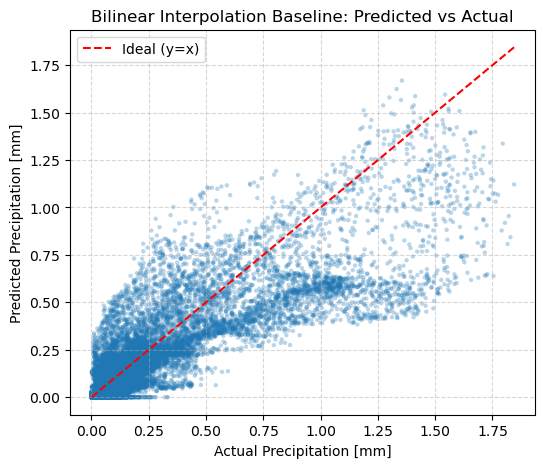

In [22]:
# Implement the baseline: Bilinear interpolation of total precipitation
# First, calculate the total precipitation in the input data
total_precip_in = data_in_area['tp'] * 1000 # input in meters, so convert to mm 
# We are predicting the time-mean precipitation, so let's mean over time first
# (Interpolating the mean is equivalent to finding the mean of interpolated values for bilinear interpolation)
mean_total_precip_in = total_precip_in.mean(dim='time')

# Bilinearly interpolate to the high-resolution output grid
interp_baseline = mean_total_precip_in.interp(
    latitude=data_out_area['latitude'],
    longitude=data_out_area['longitude'],
    method='linear'
)

# Flatten to match the target `y`
y_pred_baseline_full = interp_baseline.values.flatten()
# Remake mask to drop NaNs
mask = ~np.isnan(y_pred_baseline_full) & ~np.isnan(y)
y_pred_baseline = y_pred_baseline_full[mask]
y_actual = y[mask]

# Evaluate on the full dataset X, y
metrics["Interpolation"] = evaluate_and_plot(y_actual, y_pred_baseline, "Bilinear Interpolation Baseline")


In [53]:
def percent_improvement(baseline, model_metric):
    return (baseline - model_metric) / baseline * 100

for model_name in ["LR", "MLP"]:
    print(f"--- Improvement of {model_name} over Interpolation Baseline ---")
    imp_mae = percent_improvement(metrics["Interpolation"][0], metrics[model_name][0])
    imp_95 = percent_improvement(metrics["Interpolation"][1], metrics[model_name][1])
    imp_99 = percent_improvement(metrics["Interpolation"][2], metrics[model_name][2])
    
    print(f"MAE (CRPS) Improvement: {imp_mae:.2f}%")
    print(f"95th Percentile MAE Improvement: {imp_95:.2f}%")
    print(f"99th Percentile MAE Improvement: {imp_99:.2f}%")
    print()


--- Improvement of LR over Interpolation Baseline ---
MAE (CRPS) Improvement: 54.14%
95th Percentile MAE Improvement: 67.41%
99th Percentile MAE Improvement: 65.42%

--- Improvement of MLP over Interpolation Baseline ---
MAE (CRPS) Improvement: 49.88%
95th Percentile MAE Improvement: 69.11%
99th Percentile MAE Improvement: 70.96%

